# Overview - ML Models: Decision Tree, Bagging, Random Forest, AdaBoost, XGBoost

**Student:** Bryan Montaguano
**Course:** Machine Learning

Short notebook with one example of each model family asked by the professor. Same dataset is used for all of them so the results are easy to compare at the end.

## 1. Setup and dataset

We are using the **Breast Cancer** dataset that comes built-in with sklearn (no download needed). It's a binary classification problem: predict if a tumor is malignant or benign based on 30 numeric features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("X shape:", X.shape)
print("Classes:", list(data.target_names))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

X shape: (569, 30)
Classes: [np.str_('malignant'), np.str_('benign')]
Train size: 455 | Test size: 114


## 2. Decision Tree

A single tree that splits the data based on feature values. Easy to read and interpret, but a deep tree can overfit pretty fast.

In [3]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_preds)

print(f"Decision Tree accuracy: {tree_acc:.4f}")

Decision Tree accuracy: 0.9474


## 3. Bagging Classifier

Bagging (Bootstrap Aggregating) trains several copies of the same model (here, small decision trees) on random subsets of the training data, sampled **with replacement**. Then it averages/votes the predictions. This mainly helps to reduce variance compared to one single tree.

In [4]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)

bagging_preds = bagging_model.predict(X_test)
bagging_acc = accuracy_score(y_test, bagging_preds)

print(f"Bagging accuracy: {bagging_acc:.4f}")

Bagging accuracy: 0.9561


## 4. Random Forest

Random Forest is basically Bagging, but specifically with decision trees, plus one extra trick: at every split, it only looks at a random subset of features instead of all of them. That makes the trees less correlated with each other, which usually gives a small but real boost over plain Bagging.

In [5]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest accuracy: {rf_acc:.4f}")

Random Forest accuracy: 0.9649


## 5. AdaBoost

Boosting works differently from bagging: models are trained one after another (sequentially) instead of in parallel. Each new model pays more attention to the examples the previous ones got wrong. AdaBoost does this by increasing the **weight** of the misclassified samples at every round.

In [6]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
ada_model.fit(X_train, y_train)

ada_preds = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, ada_preds)

print(f"AdaBoost accuracy: {ada_acc:.4f}")

AdaBoost accuracy: 0.9737


## 6. XGBoost

XGBoost (Extreme Gradient Boosting) is also a boosting method, but instead of reweighting samples like AdaBoost, each new tree is fit to the **residual errors** of the previous ones (basically gradient descent applied to the loss function). It's one of the most popular algorithms for tabular data because it's fast and usually very accurate.

In [7]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost accuracy: {xgb_acc:.4f}")

XGBoost accuracy: 0.9561


## 7. Comparing all five models

           Model  Accuracy
0       AdaBoost  0.973684
1  Random Forest  0.964912
2        Bagging  0.956140
3        XGBoost  0.956140
4  Decision Tree  0.947368


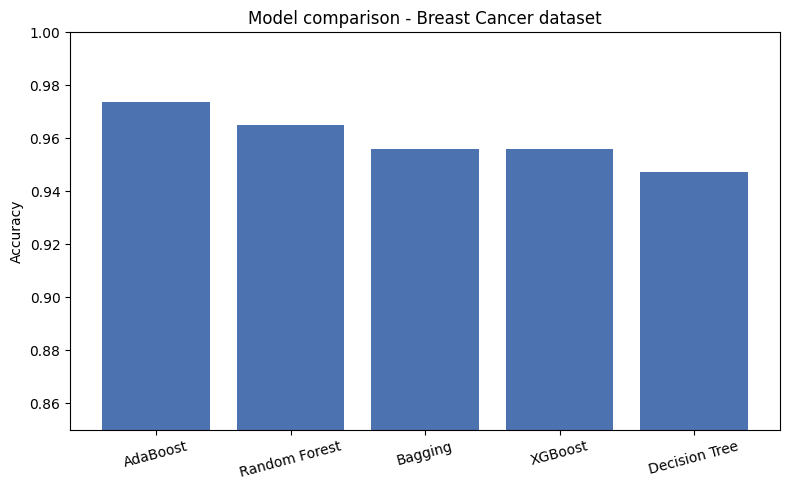

In [8]:
results = {
    "Decision Tree": tree_acc,
    "Bagging": bagging_acc,
    "Random Forest": rf_acc,
    "AdaBoost": ada_acc,
    "XGBoost": xgb_acc
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"], color="#4C72B0")
plt.ylim(0.85, 1.0)
plt.ylabel("Accuracy")
plt.title("Model comparison - Breast Cancer dataset")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Conclusion

- **Decision Tree:** one single tree, fast and easy to interpret, but can overfit.
- **Bagging:** many trees trained on random samples (with replacement), then averaged. Reduces variance.
- **Random Forest:** Bagging + random feature selection at each split. Usually better than plain Bagging.
- **AdaBoost:** boosting, trains trees one by one, giving more weight to the samples the previous tree got wrong.
- **XGBoost:** boosting too, but each tree is fit to correct the residual errors of the previous ones. Usually the strongest of the five here.

All five models are tree-based, the real difference is **how** they combine multiple trees (or just use one) to get the final prediction: single tree vs. parallel bagging vs. sequential boosting.